# SSH Model

**Author:** Gabriel Maresch

**available at** 

In [1]:
using Pkg
using Plots
using LinearAlgebra

In [2]:
function build_SSH(J1, J2, E0, N, pbc=false)
    diag0 = [E0 for _ in 1:N]
    diag1 = [i%2 == 0 ? J2 : J1 for i in 1:(N-1)]
    H = zeros(N,N)
    H = diagm(-1=> diag1, 1=> diag1, 0=> diag0)
    if pbc
        H[1, N] = (N%2 == 1 ? J1 : J2)
        H[N, 1] = H[1,N]
    end
    return H
end

display(build_SSH(1.,2.,0.,6, true))

6×6 Matrix{Float64}:
 0.0  1.0  0.0  0.0  0.0  2.0
 1.0  0.0  2.0  0.0  0.0  0.0
 0.0  2.0  0.0  1.0  0.0  0.0
 0.0  0.0  1.0  0.0  2.0  0.0
 0.0  0.0  0.0  2.0  0.0  1.0
 2.0  0.0  0.0  0.0  1.0  0.0

In [3]:
N=100
@assert N%2 == 0

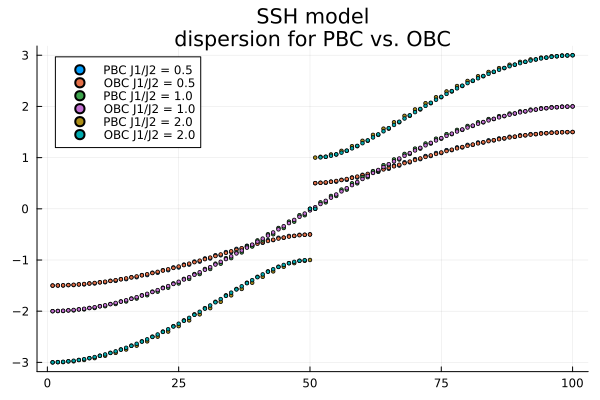

In [27]:
J2s = [0.5, 1 , 2]

p = plot(title="SSH model\ndispersion for PBC vs. OBC")
for J2 in J2s 

    H_pbc = build_SSH(1., J2, 0.,N, true)
    lambdas_pbc = eigen(H_pbc).values

    H_obc = build_SSH(1., J2 ,0.,N, false)
    lambdas_obc = eigen(H_obc).values
    boundary_states = eigen(H_obc).vectors[:, N ÷ 2 : N ÷ 2 + 1]

    scatter!(p, lambdas_pbc, label="PBC J1/J2 = $(J2)", markersize = 2)
    scatter!(p, lambdas_obc, label="OBC J1/J2 = $(J2)",  markersize = 2)
end
display(p)


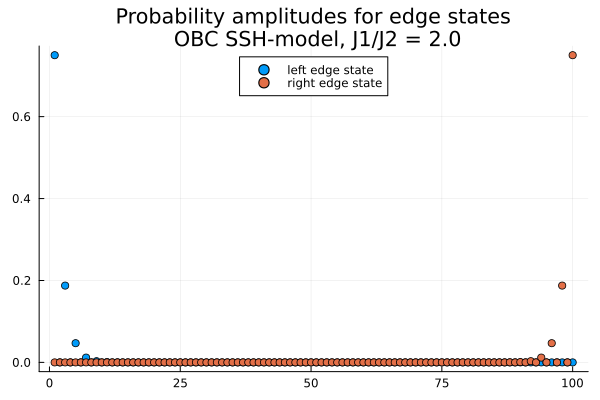

In [25]:
X = diagm([i for i in 1:N])

X_edge = zeros(2,2)
X_edge[1,1] = boundary_states[:,1]'*X*boundary_states[:,1]
X_edge[1,2] = boundary_states[:,1]'*X*boundary_states[:,2]
X_edge[2,1] = boundary_states[:,2]'*X*boundary_states[:,1]
X_edge[2,2] = boundary_states[:,2]'*X*boundary_states[:,2]

T = eigen(X_edge).vectors

edge_left = boundary_states * T[:,1]
edge_right = boundary_states * T[:,2]

edge = scatter(abs.(edge_left).^2, label="left edge state", legend=:top)
scatter!(edge, abs.(edge_right).^2, label="right edge state", title="Probability amplitudes for edge states\n OBC SSH-model, J1/J2 = $(J2s[end])")